In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import joblib

# Data Preparation

In [3]:
df = pd.read_csv("/kaggle/input/auto-scaling-analysis-data/train.csv")
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d/%b/%Y:%H:%M:%S %z"
)

df = df.set_index("timestamp")

df.head()

,request_src,method,dest_path,http_type,status,bytes
timestamp,,,,,,
1995-07-01 00:00:01-04:00,199.72.81.55,GET,/history/apollo/,HTTP/1.0,200,6245
1995-07-01 00:00:06-04:00,unicomp6.unicomp.net,GET,/shuttle/countdown/,HTTP/1.0,200,3985
1995-07-01 00:00:09-04:00,199.120.110.21,GET,/shuttle/missions/sts-73/mission-sts-73.html,HTTP/1.0,200,4085
1995-07-01 00:00:11-04:00,burger.letters.com,GET,/shuttle/countdown/liftoff.html,HTTP/1.0,304,0
1995-07-01 00:00:11-04:00,199.120.110.21,GET,/shuttle/missions/sts-73/sts-73-patch-small.gif,HTTP/1.0,200,4179


In [4]:
# Define training data
chunk_time = '5min'
feature = 'request_count'

df["request_count"] = 1

# Split by 1m
df_chunk = df.resample(chunk_time).agg({
    "request_count": "sum",
    "bytes": "sum",
})

series = df_chunk[feature].values

df_chunk.head()

,request_count,bytes
timestamp,,
1995-07-01 00:00:00-04:00,301,5277675
1995-07-01 00:05:00-04:00,267,5041043
1995-07-01 00:10:00-04:00,242,6111846
1995-07-01 00:15:00-04:00,282,4559748
1995-07-01 00:20:00-04:00,319,7262385


In [5]:
PARAMS = {
    'train_window': 120,   # Giảm window xuống để model tập trung vào pattern gần
    'predict_window': 1,
    'batch_size': 64,     # Batch nhỏ giúp thoát local minima tốt hơn
    'hidden_size': 64,
    'num_layers': 2,      # Tăng độ sâu mô hình
    'dropout': 0.2,       # Thêm dropout để tránh overfit
    'lr': 1e-3,           # Tăng LR lên
    'epochs': 50
}

In [6]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        # Input: cửa sổ [i : i+window]
        # Target: giá trị tiếp theo [i+window]
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size]
        return x, y

In [7]:
# Dùng MinMaxScaler tốt hơn cho LSTM (tanh activation)
# scaler = MinMaxScaler(feature_range=(0, 1))
scaler = StandardScaler()
series_scaled = scaler.fit_transform(series.reshape(-1, 1))
joblib.dump(scaler, 'scaler.pkl')

# Split Train/Val
train_size = int(len(series_scaled) * 0.8)
train_data = series_scaled[:train_size]
val_data = series_scaled[train_size:]

In [8]:
train_ds = TimeSeriesDataset(train_data, PARAMS['train_window'])
val_ds = TimeSeriesDataset(val_data, PARAMS['train_window'])

train_loader = DataLoader(train_ds, batch_size=PARAMS['batch_size'], shuffle=True)
# Val loader không shuffle để vẽ biểu đồ cho đúng thứ tự
val_loader = DataLoader(val_ds, batch_size=PARAMS['batch_size'], shuffle=False)

print("Training size:", len(train_data), '\nValid size:', len(val_data))

Training size: 12211 
Valid size: 3053


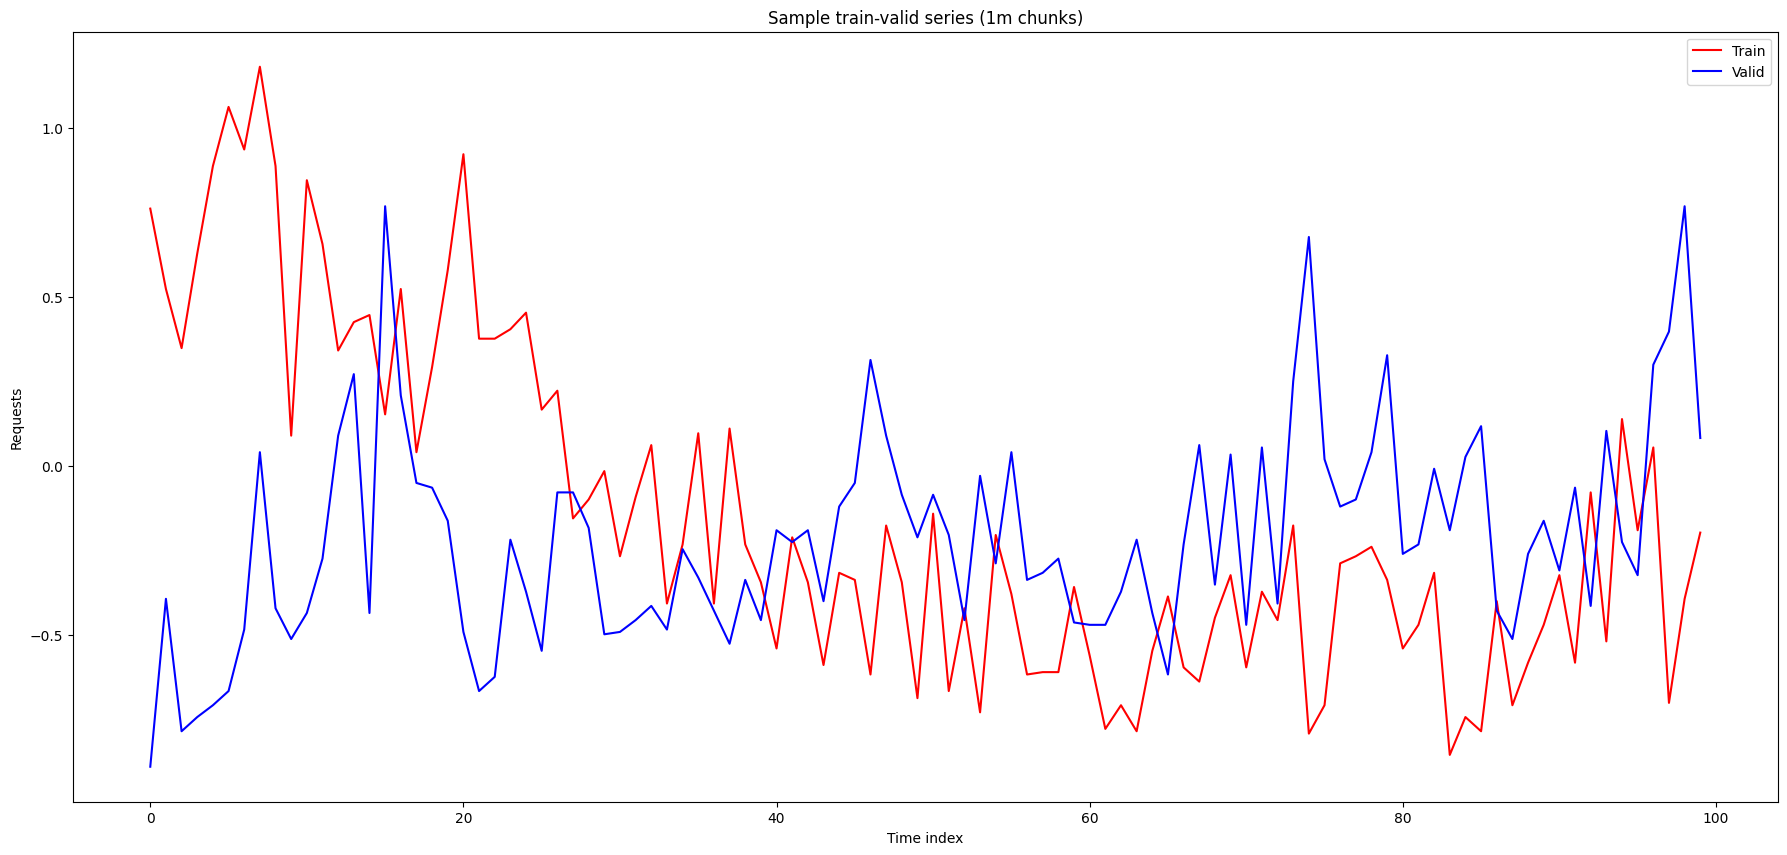

In [9]:
# Plot train-valid
sample_size = 100
plt.figure(figsize=(22,10))
plt.title("Sample train-valid series (1m chunks)")
plt.xlabel("Time index")
plt.ylabel("Requests")
plt.plot(train_data[:sample_size], color='red', label='Train')
plt.plot(val_data[:sample_size], color='blue', label='Valid')
plt.legend()
plt.show()

In [10]:
for i in train_loader:
  print("Input shape:", i[0].shape, "\nOutput shape:", i[1].shape)
  break;

Input shape: torch.Size([64, 120, 1]) 
Output shape: torch.Size([64, 1])


# LSTM Model training

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.lstm(x)

        last_out = out[:, -1, :] 
        prediction = self.fc(last_out)
        return prediction

### SMAPE Loss

In [12]:
class SMAPELoss(nn.Module):
    def __init__(self, epsilon=0.1):
        super(SMAPELoss, self).__init__()
        self.epsilon = epsilon

    def forward(self, pred, target):
        """
        Tính toán Smooth SMAPE để có thể backprop được.
        Công thức gốc: 2 * |y_pred - y_true| / (|y_pred| + |y_true|)
        Công thức smooth: tránh chia cho 0 bằng cách thêm epsilon vào mẫu số.
        """
        pred = pred.view_as(target)
        
        diff = torch.abs(pred - target)
        # max(sum, 0.5 + epsilon) để chặn dưới
        denominator = torch.abs(pred) + torch.abs(target) + self.epsilon
        smape = 2.0 * diff / denominator
        
        return torch.mean(smape)

criterion = SMAPELoss(epsilon=0.1)

# Ví dụ test
y_pred = torch.tensor([100.0, 0.0, 10.0], requires_grad=True)
y_true = torch.tensor([110.0, 0.0, 10.0])

loss = criterion(y_pred, y_true)
loss.backward() 
print("Test Loss:", loss.item())

Test Loss: 0.03173092007637024


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMModel(
    input_size=1,
    hidden_size=PARAMS['hidden_size'],
    num_layers=PARAMS['num_layers'],
    output_size=1,
    dropout=PARAMS['dropout']
).to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=PARAMS['lr'])

### Training phase

In [14]:
best_loss = float('inf')
history = {'train': [], 'val': []}

print(f"Training on {device}...")

for epoch in range(PARAMS['epochs']):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm.pth')
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Training on cuda...
Epoch 05 | Train Loss: 0.247615 | Val Loss: 0.235597
Epoch 10 | Train Loss: 0.242146 | Val Loss: 0.233853
Epoch 15 | Train Loss: 0.241458 | Val Loss: 0.234907
Epoch 20 | Train Loss: 0.241732 | Val Loss: 0.234790
Epoch 25 | Train Loss: 0.239072 | Val Loss: 0.238738
Epoch 30 | Train Loss: 0.237892 | Val Loss: 0.235666
Epoch 35 | Train Loss: 0.236853 | Val Loss: 0.234831
Epoch 40 | Train Loss: 0.236429 | Val Loss: 0.234412
Epoch 45 | Train Loss: 0.236275 | Val Loss: 0.233634
Epoch 50 | Train Loss: 0.235423 | Val Loss: 0.235767


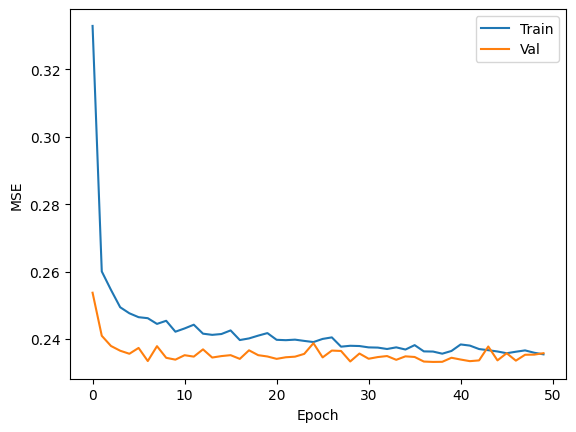

In [15]:
plt.plot(history["train"], label="Train")
plt.plot(history["val"], label="Val")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

### Evaluation phase

In [16]:
model.load_state_dict(torch.load('best_lstm.pth', map_location=device))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch = x_batch.to(device)
        pred = model(x_batch)
        # Đưa về CPU numpy
        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

# Gộp các batch lại
predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# Inverse transform để về giá trị request thật
predictions_inv = scaler.inverse_transform(predictions)
actuals_inv = scaler.inverse_transform(actuals)

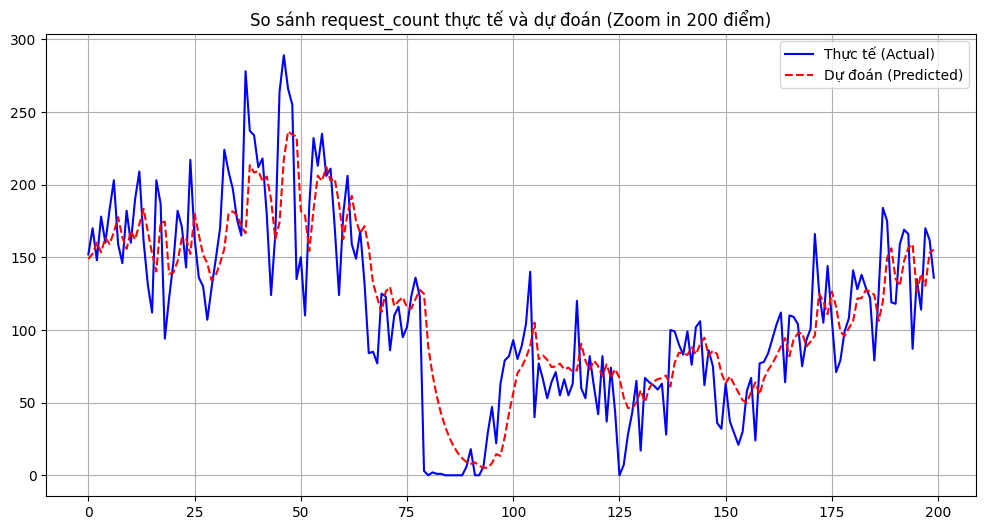

In [17]:
limit = 200 

plt.figure(figsize=(12, 6))
plt.plot(actuals_inv[:limit], label='Thực tế (Actual)', color='blue')
plt.plot(predictions_inv[:limit], label='Dự đoán (Predicted)', color='red', linestyle='--')
plt.title(f"So sánh {feature} thực tế và dự đoán (Zoom in 200 điểm)")
plt.legend()
plt.grid(True)
plt.show()

# Evaluate on test data

In [18]:
test_df = pd.read_csv('/kaggle/input/auto-scaling-analysis-data/test.csv')

test_df["timestamp"] = pd.to_datetime(
    test_df["timestamp"],
    format="%d/%b/%Y:%H:%M:%S %z"
)

test_df = test_df.set_index("timestamp")
test_df["request_count"] = 1
test_df = test_df.resample(chunk_time).agg({
    "request_count": "sum",
    "bytes": "sum",
})
test_df.head()

,request_count,bytes
timestamp,,
1995-08-23 00:00:00-04:00,210,2518422
1995-08-23 00:05:00-04:00,125,2954949
1995-08-23 00:10:00-04:00,108,3450646
1995-08-23 00:15:00-04:00,173,2986860
1995-08-23 00:20:00-04:00,130,1897617


In [19]:
# Scale
test_data = test_df[feature].values.reshape(-1, 1)
test_series_scaled = scaler.transform(test_data)
print("Test shape:", len(test_data))

Test shape: 2592


In [20]:
test_ds = TimeSeriesDataset(test_series_scaled, PARAMS['train_window'])
test_loader = DataLoader(test_ds, batch_size=PARAMS['batch_size'], shuffle=False)

# model
model.load_state_dict(torch.load('best_lstm.pth', map_location=device))
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        pred = model(x_batch)

        predictions.append(pred.cpu().numpy())
        actuals.append(y_batch.numpy())

# Gộp các batch lại
predictions = np.concatenate(predictions)
actuals = np.concatenate(actuals)

# Inverse transform để về giá trị request thật
predictions_inv = scaler.inverse_transform(predictions)
actuals_inv = scaler.inverse_transform(actuals)

### Metrics evaluation

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(actuals_inv, predictions_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals_inv, predictions_inv)

# MAPE (Mean Absolute Percentage Error)
# Cho biết model sai lệch bao nhiêu % so với thực tế.
def calculate_mape(y_true, y_pred):
    # MAPE
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # SMAPE
    epsilon = 0.1
    summ = np.maximum(np.abs(y_true) + np.abs(y_pred) + epsilon, 0.5 + epsilon)
    smape = np.mean((np.abs(y_pred - y_true) / summ) * 2.0) * 100
    return mape, smape

mape, smape = calculate_mape(actuals_inv, predictions_inv)

# R2 Score (Coefficient of Determination)
# Đo độ phù hợp của mô hình (càng gần 1 càng tốt, âm là model tệ hơn đoán bừa)
r2 = r2_score(actuals_inv, predictions_inv)

print("-" * 30)
print(f"Evaluation Metrics:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"SMAPE: {smape:.2f}%")
print(f"R2   : {r2:.4f}")
print("-" * 30)

------------------------------
Evaluation Metrics:
MSE  : 2182.2175
RMSE : 46.7142
MAE  : 35.1521
MAPE : 10394666.00%
SMAPE: 20.52%
R2   : 0.8575
------------------------------


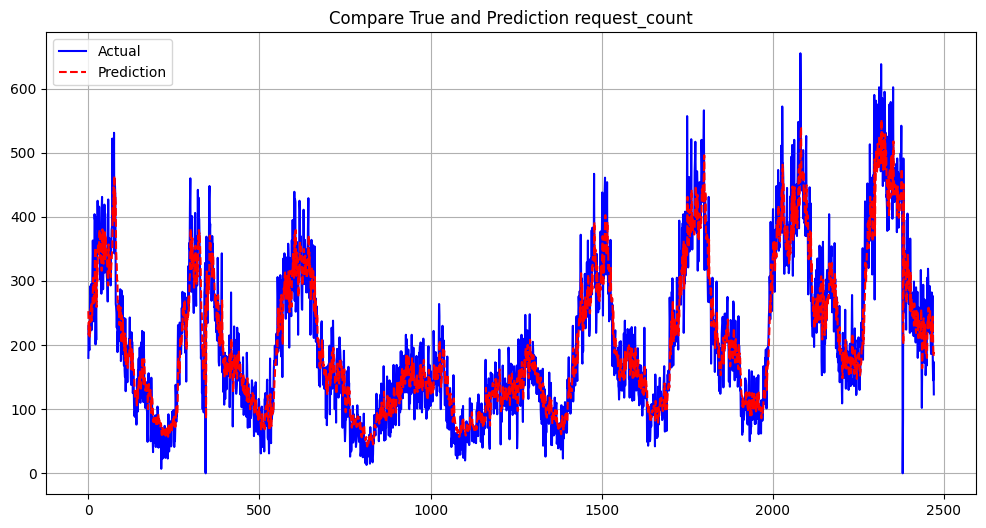

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(actuals_inv, label='Actual', color='blue')
plt.plot(predictions_inv, label='Prediction', color='red', linestyle='--')
plt.title(f"Compare True and Prediction {feature}")
plt.legend()
plt.grid(True)
plt.show()

## Spike detection

In [23]:
from scipy.signal import find_peaks

class EventEvaluator:
    def __init__(self, tolerance=1):
        """
        tolerance: Số bước thời gian cho phép sai lệch.
                   Ví dụ tolerance=2 nghĩa là đỉnh dự đoán lệch sớm/muộn 2 nhịp 
                   so với đỉnh thật vẫn được tính là đúng (True Positive).
        """
        self.tolerance = tolerance

    def _match_events(self, true_indices, pred_indices):
        """
        Hàm cốt lõi để ghép cặp sự kiện giữa thực tế và dự đoán 
        dựa trên khoảng cách thời gian gần nhất.
        """
        tp = 0  # True Positives
        matched_pred = set()
        matched_true = set()
        
        # Tạo danh sách các cặp ứng viên có thể match (khoảng cách <= tolerance)
        candidates = []
        for t_idx in true_indices:
            for p_idx in pred_indices:
                dist = abs(t_idx - p_idx)
                if dist <= self.tolerance:
                    candidates.append((dist, t_idx, p_idx))
        
        # Sắp xếp ưu tiên các cặp gần nhau nhất trước
        candidates.sort(key=lambda x: x[0])
        
        # Duyệt và ghép cặp (Greedy matching)
        for _, t_idx, p_idx in candidates:
            if t_idx not in matched_true and p_idx not in matched_pred:
                matched_true.add(t_idx)
                matched_pred.add(p_idx)
                tp += 1
                
        fn = len(true_indices) - len(matched_true) # Có thật mà không đoán được
        fp = len(pred_indices) - len(matched_pred) # Đoán mà không có thật
        
        return tp, fp, fn

    def _calculate_metrics(self, tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        return {
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "TP": tp, "FP": fp, "FN": fn
        }

    def evaluate_spikes(self, y_true, y_pred, threshold_std=3):
        """
        Đánh giá Spikes (các điểm đột biến vượt quá giới hạn Z-score).
        Spike được định nghĩa là giá trị > mean + k*std
        """
        # Tính ngưỡng dựa trên dữ liệu thật
        mean = np.mean(y_true)
        std = np.std(y_true)
        limit = mean + threshold_std * std
        
        true_spikes = np.where(y_true > limit)[0]
        pred_spikes = np.where(y_pred > limit)[0]
        
        tp, fp, fn = self._match_events(true_spikes, pred_spikes)
        return self._calculate_metrics(tp, fp, fn)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


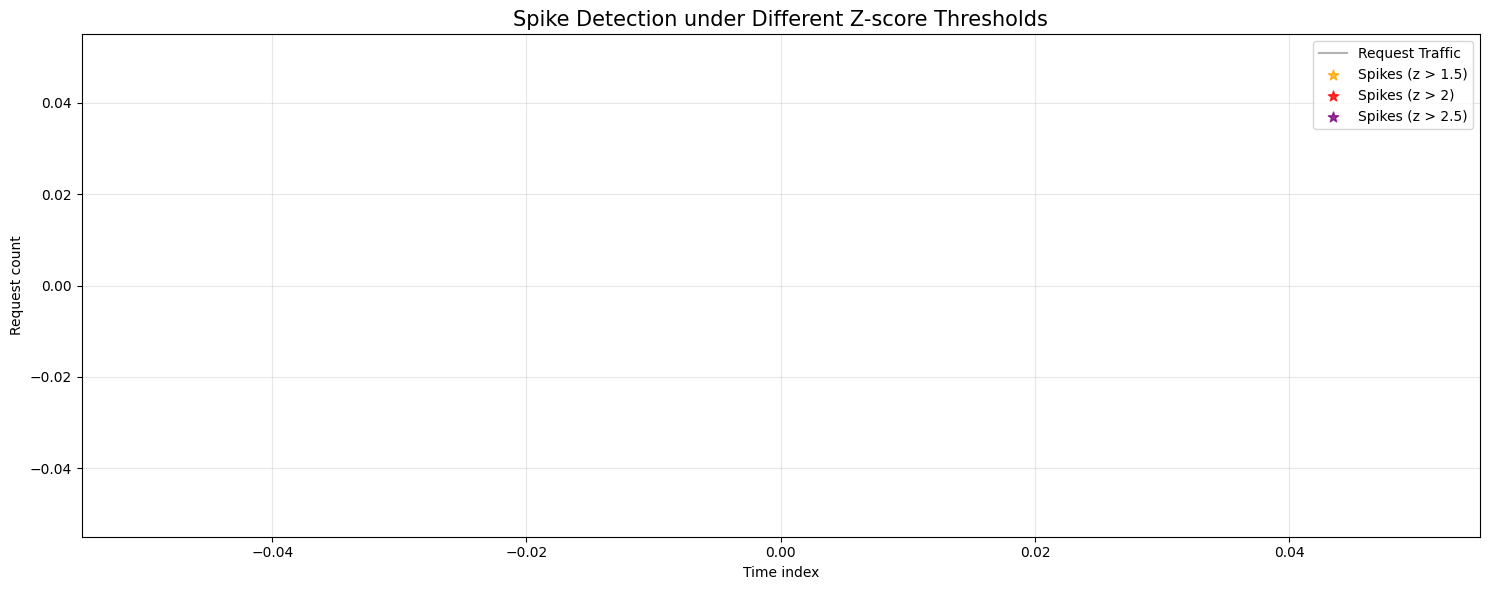

In [24]:
y = actuals[8000:, 0]
x = np.arange(len(y))

mean = np.mean(y)
std = np.std(y)

thresholds = [1.5, 2, 2.5]
colors = ['orange', 'red', 'purple']

plt.figure(figsize=(15, 6))
plt.plot(x, y, label='Request Traffic', color='gray', alpha=0.6)

for thres, color in zip(thresholds, colors):
    spikes = np.where(np.abs(y - mean) > thres * std)[0]

    plt.scatter(
        x[spikes],
        y[spikes],
        s=60,
        marker='*',
        color=color,
        alpha=0.8,
        label=f'Spikes (z > {thres})',
        zorder=4
    )

    # Vẽ ngưỡng
    plt.axhline(mean + thres * std, color=color, linestyle='--', alpha=0.3)
    plt.axhline(mean - thres * std, color=color, linestyle='--', alpha=0.3)

plt.title("Spike Detection under Different Z-score Thresholds", fontsize=15)
plt.xlabel("Time index")
plt.ylabel("Request count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
from pprint import pprint

evaluator = EventEvaluator(tolerance=2)

spike_results = {}

for thres in thresholds:
    metrics = evaluator.evaluate_spikes(
        actuals_inv.flatten(),
        predictions_inv.flatten(),
        threshold_std=thres
    )
    spike_results[f"z>{thres}"] = metrics

print("\n--- SPIKE DETECTION BY Z-SCORE ---")
pprint(spike_results)


--- SPIKE DETECTION BY Z-SCORE ---
{'z>1.5': {'F1-Score': 0.8054298642533937,
           'FN': 70,
           'FP': 16,
           'Precision': 0.9175257731958762,
           'Recall': 0.717741935483871,
           'TP': 178},
 'z>2': {'F1-Score': 0.6440677966101694,
         'FN': 54,
         'FP': 9,
         'Precision': 0.8636363636363636,
         'Recall': 0.5135135135135135,
         'TP': 57},
 'z>2.5': {'F1-Score': 0.43636363636363634,
           'FN': 31,
           'FP': 0,
           'Precision': 1.0,
           'Recall': 0.27906976744186046,
           'TP': 12}}


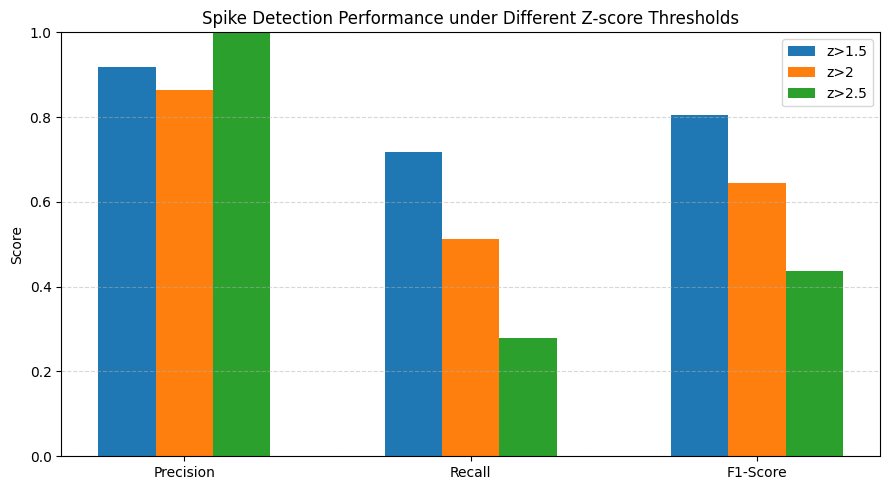

In [26]:
metric_names = ["Precision", "Recall", "F1-Score"]

x = np.arange(len(metric_names))
width = 0.2

plt.figure(figsize=(9,5))

for i, (label, vals) in enumerate(spike_results.items()):
    scores = [vals[m] for m in metric_names]
    plt.bar(x + i * width, scores, width, label=label)

plt.xticks(x + width, metric_names)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Spike Detection Performance under Different Z-score Thresholds")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()